In [1]:
# Put this in a cell BEFORE importing paddleocr / creating PaddleOCR
import os
os.environ["FLAGS_use_mkldnn"] = "0"     # disable oneDNN (MKLDNN)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # sometimes helps on Windows envs
os.environ["FLAGS_use_new_executor"] = "0"

In [2]:
import numpy as np
import json
from PIL import Image, ImageDraw, ImageFont
import re
import unicodedata
from pathlib import Path
from typing import List, Dict, Any, Tuple
import cv2

In [3]:
INPUT_PNG_DIR = Path("./data/gt_imgs_tech/otsu")          # <-- change if needed
OUT_DIR  = Path("./outputs/en_outputs_test")

OUT_DIR.mkdir(parents=True, exist_ok=True)

png_files = sorted(INPUT_PNG_DIR.glob("*.png"))
print("Found PNGs:", len(png_files))
if png_files:
    print("Example:", png_files[0])

Found PNGs: 6
Example: data\gt_imgs_tech\otsu\pg_1.png


In [4]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    lang='en',
    ocr_version="PP-OCRv5",
    text_detection_model_name="PP-OCRv5_server_det",
    text_recognition_model_name="PP-OCRv5_server_rec",
    use_doc_orientation_classify=True,
    use_doc_unwarping=True,
    use_textline_orientation=True,
    device = "gpu")

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
C:\Users\abcdj\AppData\Local\Temp\ipykernel_8484\3184798223.py:3: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr = PaddleOCR(
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\abcdj\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\abcdj\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\abcdj\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)


In [5]:
import json
import numpy as np


def poly_to_xyxy(poly):
    pts = np.array(poly, dtype=np.float32)
    x1 = float(np.min(pts[:, 0]))
    y1 = float(np.min(pts[:, 1]))
    x2 = float(np.max(pts[:, 0]))
    y2 = float(np.max(pts[:, 1]))
    return [x1, y1, x2, y2]


def box_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)


def box_height(box):
    return box[3] - box[1]


def box_width(box):
    return box[2] - box[0]


def horizontal_gap(box1, box2):
    # box2 assumed to be on the right
    return box2[0] - box1[2]


def merge_boxes(box1, box2):
    return [
        min(box1[0], box2[0]),
        min(box1[1], box2[1]),
        max(box1[2], box2[2]),
        max(box1[3], box2[3]),
    ]


def make_poly_from_box(box):
    x1, y1, x2, y2 = box
    return [
        [int(round(x1)), int(round(y1))],
        [int(round(x2)), int(round(y1))],
        [int(round(x2)), int(round(y2))],
        [int(round(x1)), int(round(y2))],
    ]


def should_merge_by_gap_and_center(box1, box2,
                                   max_xcenter_diff_ratio=0.45,
                                   max_ygap_ratio=1.0,
                                   max_abs_gap=45):
    """
    Swapped x/y version of the previous function.

    Merge if:
    1. x centers are close enough
    2. vertical gap is small enough
    """

    c1x, c1y = box_center(box1)
    c2x, c2y = box_center(box2)

    w1 = box_width(box1)
    w2 = box_width(box2)
    avg_w = (w1 + w2) / 2.0

    # alignment using x centers
    xcenter_diff = abs(c1x - c2x)
    if xcenter_diff > avg_w * max_xcenter_diff_ratio:
        return False

    # vertical gap
    gap = box2[1] - box1[3]

    if gap <= 0:
        return True

    allowed_gap = min(max_abs_gap, avg_w * max_ygap_ratio)
    return gap <= allowed_gap

import re
import numpy as np


def poly_to_xyxy(poly):
    pts = np.array(poly, dtype=np.float32)
    x1 = float(np.min(pts[:, 0]))
    y1 = float(np.min(pts[:, 1]))
    x2 = float(np.max(pts[:, 0]))
    y2 = float(np.max(pts[:, 1]))
    return [x1, y1, x2, y2]


def is_english_text(text):
    """
    Keep only strings made of English letters, digits, spaces,
    and common punctuation.
    """
    t = text.strip()
    if not t:
        return False

    return re.fullmatch(r"[A-Za-z0-9\s.,!?;:'\"()\-\[\]/&]+", t) is not None


def filter_bad_english_boxes(
    polys,
    texts,
    scores=None,
    min_w=12,
    min_h=12,
    min_area=180,
):
    """
    Remove a box if:
    1. it is too small
    2. text length is 1
    3. text is not English-compatible
    """

    kept_polys = []
    kept_texts = []
    kept_scores = [] if scores is not None else None

    removed = []

    for i, (poly, text) in enumerate(zip(polys, texts)):
        t = text.strip()
        x1, y1, x2, y2 = poly_to_xyxy(poly)
        w = x2 - x1
        h = y2 - y1
        area = w * h

        remove_reason = None

        if w < min_w or h < min_h or area < min_area:
            remove_reason = "too_small"
        elif len(t) == 1:
            remove_reason = "single_char"
        elif not is_english_text(t):
            remove_reason = "non_english"

        if remove_reason is not None:
            removed.append({
                "index": i,
                "text": text,
                "box": [x1, y1, x2, y2],
                "reason": remove_reason
            })
            continue

        kept_polys.append(poly)
        kept_texts.append(text)
        if scores is not None:
            kept_scores.append(scores[i])

    if scores is not None:
        return kept_polys, kept_texts, kept_scores
    return kept_polys, kept_texts


def merge_english_boxes_center_gap(polys, texts, scores=None,
                                   max_xcenter_diff_ratio=0.45,
                                   max_ygap_ratio=1.0,
                                   max_abs_gap=45):
    items = []
    for i, (poly, text) in enumerate(zip(polys, texts)):
        box = poly_to_xyxy(poly)
        items.append({
            "poly": poly,
            "box": box,
            "text": text,
            "score": scores[i] if scores is not None else None
        })

    # top-to-bottom, then left-to-right
    items.sort(key=lambda d: (d["box"][1], box_center(d["box"])[0]))

    merged = []
    used = [False] * len(items)

    for i in range(len(items)):
        if used[i]:
            continue

        curr_box = items[i]["box"][:]
        curr_texts = [items[i]["text"]]
        curr_scores = []
        if items[i]["score"] is not None:
            curr_scores.append(items[i]["score"])

        used[i] = True

        while True:
            best_j = None
            best_gap = None

            for j in range(len(items)):
                if used[j]:
                    continue

                next_box = items[j]["box"]

                # only consider boxes to the right, or slightly overlapping
                gap = next_box[1] - curr_box[3]
                if gap < -20:
                    continue

                if should_merge_by_gap_and_center(
                    curr_box,
                    next_box,
                    max_xcenter_diff_ratio=max_xcenter_diff_ratio,
                    max_ygap_ratio=max_ygap_ratio,
                    max_abs_gap=max_abs_gap
                ):
                    if best_j is None or gap < best_gap:
                        best_j = j
                        best_gap = gap

            if best_j is None:
                break

            curr_box = merge_boxes(curr_box, items[best_j]["box"])
            curr_texts.append(items[best_j]["text"])

            if items[best_j]["score"] is not None:
                curr_scores.append(items[best_j]["score"])

            used[best_j] = True

        merged.append({
            "poly": make_poly_from_box(curr_box),
            "text": " ".join(curr_texts),
            "score": float(np.mean(curr_scores)) if curr_scores else None
        })

    filtered_polys, filtered_texts, filtered_scores = filter_bad_english_boxes(
        [m["poly"] for m in merged],
        [m["text"] for m in merged],
        [m["score"] for m in merged] if merged and merged[0]["score"] is not None else None
    )

    filtered_merged = []
    for i, (poly, text, score) in enumerate(zip(filtered_polys, filtered_texts, filtered_scores if filtered_scores is not None else [None] * len(filtered_polys))):
        filtered_merged.append({
            "poly": poly,
            "text": text,
            "score": score
        })


    return filtered_merged

In [13]:
# function to get only important values
def create_res_dict(res_out) -> dict:
    assert len(res_out['dt_polys']) == len(res_out['rec_texts']) == len(res_out['rec_scores']), "Length mismatch in polys, texts, scores"

    return_dict = {
        'input': res_out['input_path'],
        'output_img': res_out['doc_preprocessor_res']['output_img'],
        'lang': 'en',
        'polys': res_out['dt_polys'],
        'texts': res_out['rec_texts'],
        'scores': res_out['rec_scores']
    }

    return return_dict

# helper function to display the OCR results on the image
def visualize_ocr_results(res_dict: dict) -> Image.Image:
    vis = np.array(res_dict['output_img'], dtype=np.uint8)
    vis = np.ascontiguousarray(vis)

    polys = res_dict['polys']
    for it in polys:
        pts = np.array(it, dtype=np.int32)
        cv2.polylines(vis, [pts], True, (0, 255, 0), 2)

    img_pil = Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    font = ImageFont.truetype("NotoSansCJKjp-VF.ttf", 20)

    for i, poly in enumerate(res_dict['polys']):
        pts = np.array(poly, dtype=np.int32)
        text = res_dict['texts'][i]
        x = int(np.min(pts[:, 0]))
        y = max(int(np.min(pts[:, 1])) - 24, 0)

        draw.rectangle([x, y, x + 8 * max(len(text), 1), y + 24], fill=(0, 255, 0))
        draw.text((x + 2, y), f"{i}: {text}", font=font, fill=(0, 0, 0))

    # img_rgb = cv2.cvtColor(img_pil, cv2.COLOR_BGR2RGB)
    return img_pil

def save_results(res_dicts, out_path):
    def numpy_converter(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.bool_):
            return bool(obj)
        raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")
    
    json_dir = f"{out_path}/json"
    vis_dir = f"{out_path}/vis"
    base_dir = f"{out_path}/og"
    os.makedirs(json_dir, exist_ok=True)
    os.makedirs(vis_dir, exist_ok=True)
    os.makedirs(base_dir, exist_ok=True)

    for res_dict in res_dicts:
        base_name = os.path.basename(res_dict["input"]).replace(".png", "")
        print("Saving results for:", base_name)
        json_path = os.path.join(json_dir, f"{base_name}.json")
        vis_path = os.path.join(vis_dir, f"{base_name}.png")
        base_path = os.path.join(base_dir, f"{base_name}.png")

        vis_img = visualize_ocr_results(res_dict)
        vis_img.save(vis_path)

        base_img = Image.fromarray(cv2.cvtColor(res_dict['output_img'], cv2.COLOR_BGR2RGB))
        base_img.save(base_path)

        del res_dict['output_img']

        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(res_dict, f, default=numpy_converter, ensure_ascii=False, indent=2)
        
        print(f"Saved info for: {base_name}")

def save_base(res_dicts, out_path):
    base_dir = f"{out_path}/base"
    os.makedirs(base_dir, exist_ok=True)

    for res_dict in res_dicts:
        base_name = os.path.basename(res_dict["input"]).replace(".png", "")
        print("Saving base image for:", base_name)
        base_path = os.path.join(base_dir, f"{base_name}.png")

        base_img = visualize_ocr_results(res_dict)
        base_img.save(base_path)

def undo_right_angle_rotation(img, polys, angle_deg):
    """
    angle_deg = angle used during preprocessing
    This undoes it for image + OCR polys
    Supports: 90, -90, 180, 270, -270
    """
    h, w = img.shape[:2]
    a = angle_deg % 360

    if a == 270:
        # preprocessing rotated +90, so undo with -90
        out_img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = y
                ny = w - 1 - x
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 90:
        # preprocessing rotated -90, so undo with +90
        out_img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = h - 1 - y
                ny = x
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 180:
        out_img = cv2.rotate(img, cv2.ROTATE_180)

        new_polys = []
        for poly in polys:
            new_poly = []
            for x, y in poly:
                nx = w - 1 - x
                ny = h - 1 - y
                new_poly.append([int(nx), int(ny)])
            new_polys.append(new_poly)

    elif a == 0:
        out_img = img.copy()
        new_polys = polys

    else:
        raise ValueError("Use this only for 90/180/270 rotations.")

    return out_img, new_polys

def reprocessed_main_dict(res_out):
    assert len(res_out['dt_polys']) == len(res_out['rec_texts']) == len(res_out['rec_scores']), "Length mismatch in polys, texts, scores"

    angle= res_out['doc_preprocessor_res']['angle']
    img = res_out['doc_preprocessor_res']['output_img']
    old_polys = res_out['dt_polys']

    fixed_img, fixed_polys = undo_right_angle_rotation(img, old_polys, angle)

    return_dict = {
        'input': res_out['input_path'],
        'output_img': fixed_img,
        'lang': 'en',
        'polys': fixed_polys,
        'texts': res_out['rec_texts'],
        'scores': res_out['rec_scores']
    }
    
    return return_dict

def get_merged_dict(res_dict):
    processed_dict = reprocessed_main_dict(res_dict)

    fixed_dict = processed_dict.copy()
    # display(visualize_ocr_results(fixed_dict))
    merged = merge_english_boxes_center_gap(
        fixed_dict['polys'], 
        fixed_dict['texts'], 
        fixed_dict['scores'],
        max_xcenter_diff_ratio=0.1,
        max_ygap_ratio=0.3,
        max_abs_gap=50
        )
    fixed_dict['polys'] = [m['poly'] for m in merged]
    fixed_dict['texts'] = [m['text'] for m in merged]
    fixed_dict['scores'] = [m['score'] for m in merged]
    # display(visualize_ocr_results(fixed_dict))
    return fixed_dict, processed_dict

In [14]:
ocr_dicts = []
og_dicts = []
for png_path in png_files:
    print("Processing:", png_path.name)
    res_ocr = ocr.predict(str(png_path))[0]
    out_dict, og_dict = get_merged_dict(res_ocr)
    ocr_dicts.append(out_dict)
    og_dicts.append(og_dict)

save_base(og_dicts, OUT_DIR)
save_results(ocr_dicts, OUT_DIR)

Processing: pg_1.png
Processing: pg_2.png
Processing: pg_3.png
Processing: pg_4.png
Processing: pg_5.png
Processing: pg_6.png
Saving base image for: pg_1
Saving base image for: pg_2
Saving base image for: pg_3
Saving base image for: pg_4
Saving base image for: pg_5
Saving base image for: pg_6
Saving results for: pg_1
Saved info for: pg_1
Saving results for: pg_2
Saved info for: pg_2
Saving results for: pg_3
Saved info for: pg_3
Saving results for: pg_4
Saved info for: pg_4
Saving results for: pg_5
Saved info for: pg_5
Saving results for: pg_6
Saved info for: pg_6


In [7]:
temp = png_files[2]
res_ocr = ocr.predict(str(temp))[0]
new_dict = reprocessed_main_dict(res_ocr)

In [8]:
data = new_dict.copy()
merged = merge_english_boxes_center_gap(
    polys=data["polys"],
    texts=data["texts"],
    scores=data.get("scores"),
    max_xcenter_diff_ratio=0.1,
    max_ygap_ratio=0.3,
    max_abs_gap=50
)

out = {
    "input": data.get("input"),
    "lang": data.get("lang"),
    "output_img": data.get("output_img"),
    "polys": [m["poly"] for m in merged],
    "texts": [m["text"] for m in merged],
    "scores": [m["score"] for m in merged],
}

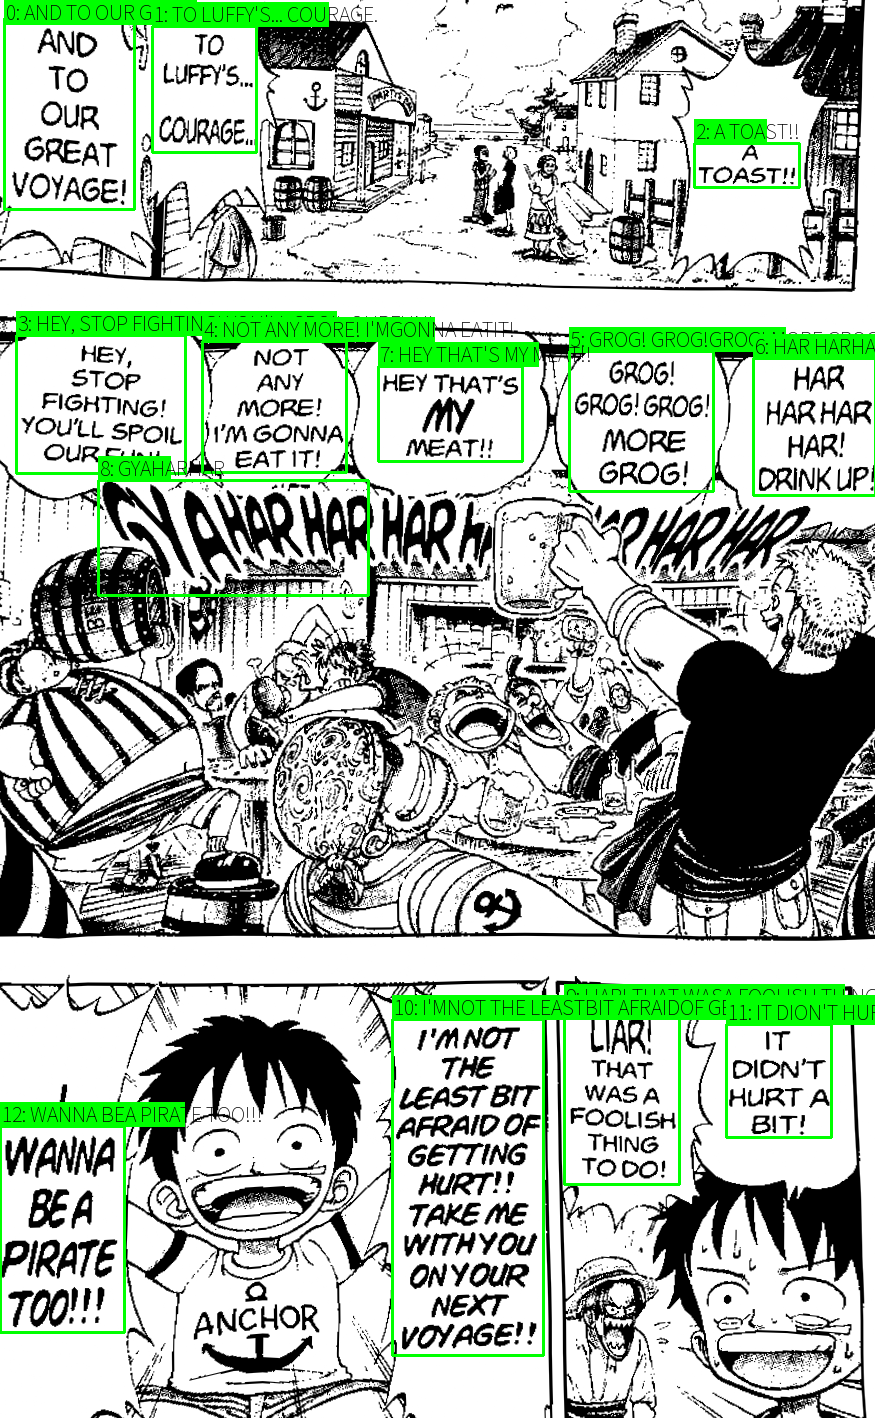

In [9]:
display(visualize_ocr_results(out))